# FallOff

In [1]:
# --------------------------------------------------------
# External packages
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

# --------------------------------------------------------
# KiRATE modules
from KiRATE.kinetics import FallOff
from KiRATE.utilities import calculate_effective_concentration

- Equations
    > $k_f \: (T, P) = k_{\infty} \left(\dfrac{P_{r}}{1+P_{r}}\right)F(T, P_r) $
    >
    > - $P_r$ is the reduce pressure computed as follow: $P_r = \dfrac{k_{0}[M]}{k_{\infty}}$
    > - $[M]$ is the concentration of the mixture, possibly including enhanced third-body efficiencies.
    > - $k_0$ and $k_{\infty}$ are the low pressure and high pressure limits of the rate constant computed as a classic Arrhenius constant.
    >
    > - $F(T, P_r)$ is the falloff function that depending on different formalism is computed in different ways.

## Lindemann

- Equations
  > $F(T, P_r) = 1$
- CHEMKIN
    >```
    > CH3 + CH3(+M) = C2H6(+M)   9.030E+16 -1.180 654.000 
    >  LOW /                     3.180E+41 -7.030 2762.00 /
    > H2/ 2/ CO/ 2/ CO2/ 3/ H2O/ 5/ ! enhanced third-body efficiencies (Optional)
    >```
- The rate constant can be represented as a Python object by directly passing a dictionary of parameters to the `FallOff` constructor. The reaction name is optional and may be omitted. Internally, the library performs consistency checks to ensure the physical validity of the provided parameters.
  
  **From dictionary**
    >```python
    > lindemann = FallOff(
    >     name="CH3+CH3(+M)=C2H6(+M)",
    >     hpl_parameters={"A": 9.030e+16, "n": -1.180, "Ea": 654.00},
    >     lpl_parameters={"A": 3.180e+41, "n": -7.030, "Ea": 2762.00},
    >     efficiencies={"H2": 2, "CO": 2, "CO2": 3, "H2O": 5},
    >     falloff_type="lindemann"
    > )
    >```

  **From CHEMKIN string**
    >```python
    > lindemann = FallOff.from_chemkin(
    >     """
    >     CH3+CH3(+M)=C2H6(+M)      9.03000E+16 -1.18000E+00 6.54000E+02
    >      LOW /                    3.18000E+41 -7.03000E+00 2.76200E+03 /
    >     H2 / 2.00000E+00 / CO / 2.00000E+00 / CO2 / 3.00000E+00 / H2O / 5.00000E+00 /
    >     """
    >)
    >```

In [2]:
# --------------------------------------------------------
# Construction from a python dictionary
lindemann = FallOff(
    name="CH3+CH3(+M)=C2H6(+M)",
    hpl_parameters={"A": 9.030e+16, "n": -1.180, "Ea": 654.00},
    lpl_parameters={"A": 3.180e+41, "n": -7.030, "Ea": 2762.00},
    efficiencies={"H2": 2, "CO": 2, "CO2": 3, "H2O": 5},
    falloff_type="lindemann"
)

# --------------------------------------------------------
# Construction from a CHEMKIN-fromatted string
lindemann = FallOff.from_chemkin(
    """
    CH3+CH3(+M)=C2H6(+M)		9.03000E+16 -1.18000E+00 6.54000E+02
     LOW /                      3.18000E+41 -7.03000E+00 2.76200E+03 /
    H2 / 2.00000E+00 / CO / 2.00000E+00 / CO2 / 3.00000E+00 / H2O / 5.00000E+00 /
    """
)

# --------------------------------------------------------
# Object inspection
print(f"Representer:\n{repr(lindemann)}\n")
print(f"String representation:\n{str(lindemann)}") # This always print the CHEMKIN-formatted string

Representer:
FallOff(
 name = CH3+CH3(+M)=C2H6(+M)
 type = lindemann
 HPL  = Arrhenius(
          name = CH3+CH3(+M)=C2H6(+M) (HPL)
          A    = 9.03000e+16
          n    = -1.18000e+00
          Ea   = 6.54000e+02
         )
 LPL  = Arrhenius(
          name = CH3+CH3(+M)=C2H6(+M) (LPL)
          A    = 3.18000e+41
          n    = -7.03000e+00
          Ea   = 2.76200e+03
         )
 efficiencies = {
  H2   = 2.00000E+00
  CO   = 2.00000E+00
  CO2  = 3.00000E+00
  H2O  = 5.00000E+00
 }
)

String representation:
CH3+CH3(+M)=C2H6(+M)		9.03000E+16 -1.18000E+00 6.54000E+02
  LOW / 3.18000E+41 -7.03000E+00 2.76200E+03 /
 H2 / 2.00000E+00 / CO / 2.00000E+00 / CO2 / 3.00000E+00 / H2O / 5.00000E+00 /


/Users/tdinelli/Documents/GitHub/KiRATE/KiRATE/kinetics/arrhenius.py:88: UserWarning: Temperature exponent n = -7.03 is unusually large. Typical values are in range [-5, 5]. Large |n| may indicate over-parameterization or fitting to a limited temperature range.
  validate_arrhenius_parameters(parameters)


## Rate constant computation

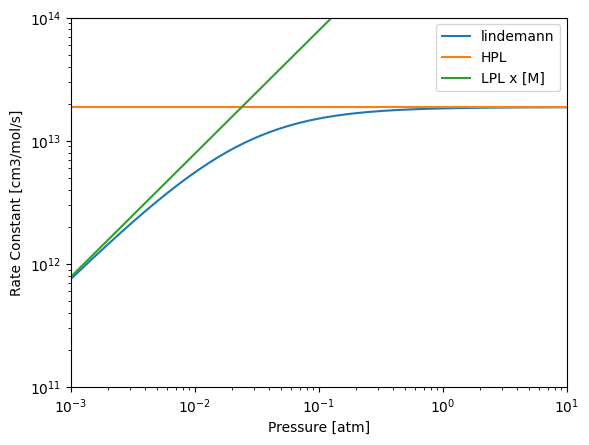

In [3]:
T_range = jnp.array([1000]*300)
P_range = jnp.logspace(jnp.log10(0.001), jnp.log10(100), 300)

# Compute the value of the High Pressure Limit rate constant
# and the Low Pressure Limit rate constant by directly accessing
# hpl and lpl attributes which are ultimately arrhenius objects
hpl = lindemann.hpl.rate_constant(T_range)
lpl = lindemann.lpl.rate_constant(T_range)

M = calculate_effective_concentration(1000, P_range)

k_lindemann = lindemann.rate_constant(1000, P_range)

fig, ax = plt.subplots()
ax.plot(P_range, k_lindemann, label="lindemann")
ax.plot(P_range, hpl, label="HPL")
ax.plot(P_range, lpl*M, label="LPL x [M]")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([1e-3, 1e1])
ax.set_ylim([1e11, 1e14])
ax.set_xlabel("Pressure [atm]")
ax.set_ylabel("Rate Constant [cm3/mol/s]")
ax.legend()
plt.show()

# TROE
- Equations
    > $F = 10^{\left(\dfrac{log_{10}Fcent}{1 + f_{1}^2}\right)}$
    > 
    > $Fcent = (1-A) exp\left(-\dfrac{T}{T_3}\right) + Aexp\left(-\dfrac{T}{T_1}\right) + exp\left(\dfrac{T_2}{T}\right)$
    >
    > $f_1 = \dfrac{log_{10}P_{r} + c}{n - 0.14\left(log_{10}P_{r} + c\right)}$
    >
    > $c = -0.4 - 0.67log_{10}Fcent$
    >
    > $n = 0.75 - 1.27 log_{10}Fcent$
- CHEMKIN
    >```
    > CH3 + CH3(+M) = C2H6(+M)   9.030E+16 -1.180 654.000 
    >  LOW /                     3.180E+41 -7.030 2762.00 /
    > TROE / 0.6041 6927.00 132.00 0.000                  / ! TROE FallOff coefficients
    > H2/ 2/ CO/ 2/ CO2/ 3/ H2O/ 5/                         ! enhanced third-body efficiencies
    >```
- The rate constant can be represented as a Python object by directly passing a dictionary of parameters to the `FallOff` constructor. The reaction name is optional and may be omitted. Internally, the library performs consistency checks to ensure the physical validity of the provided parameters.
  
  **From dictionary**
    >```python
    > troe = FallOff(
    >     name="2CH3(+M)=C2H6(+M)",
    >     hpl_parameters={"A": 9.030E+16, "n": -1.180, "Ea": 654.00},
    >     lpl_parameters={"A": 3.180E+41, "n": -7.030, "Ea": 2762.00},
    >     falloff_parameters={"A": 0.6041, "T3": 6927, "T1": 132.00, "T2": 2762.00},
    >     falloff_type="troe",
    >     efficiencies={"H2": 2, "CO": 2, "CO2": 3, "H2O": 5},
    > )
    >```

  **From CHEMKIN string**
    >```python
    > troe = FallOff.from_chemkin(
    >     """
    >     2CH3(+M)=C2H6(+M)		9.03000E+16 -1.18000E+00 6.54000E+02
    >      LOW / 3.18000E+41 -7.03000E+00 2.76200E+03 /
    >     TROE / 6.04100E-01 6.92700E+03 1.32000E+02 2.76200E+03 /
    >     H2 / 2.00000E+00 / CO / 2.00000E+00 / CO2 / 3.00000E+00 / H2O / 5.00000E+00 /
    >     """
    >)
    >```

In [4]:
# --------------------------------------------------------
# Construction from a python dictionary
troe = FallOff(
    name="2CH3(+M)=C2H6(+M)",
    hpl_parameters={"A": 9.030E+16, "n": -1.180, "Ea": 654.00},
    lpl_parameters={"A": 3.180E+41, "n": -7.030, "Ea": 2762.00},
    falloff_parameters={"A": 0.6041, "T3": 6927, "T1": 132.00, "T2": 2762.00},
    falloff_type="troe",
    efficiencies={"H2": 2, "CO": 2, "CO2": 3, "H2O": 5},
)

# --------------------------------------------------------
# Construction from a CHEMKIN-fromatted string
troe = FallOff.from_chemkin(
    """
    2CH3(+M)=C2H6(+M)		9.03000E+16 -1.18000E+00 6.54000E+02
     LOW / 3.18000E+41 -7.03000E+00 2.76200E+03 /
    TROE / 6.04100E-01 6.92700E+03 1.32000E+02 2.76200E+03 /
    H2 / 2.00000E+00 / CO / 2.00000E+00 / CO2 / 3.00000E+00 / H2O / 5.00000E+00 /
    """
)

# --------------------------------------------------------
# Object inspection
print(f"Representer:\n{repr(troe)}\n")
print(f"String representation:\n{str(troe)}") # This always print the CHEMKIN-formatted string

Representer:
FallOff(
 name = 2CH3(+M)=C2H6(+M)
 type = troe
 HPL  = Arrhenius(
          name = 2CH3(+M)=C2H6(+M) (HPL)
          A    = 9.03000e+16
          n    = -1.18000e+00
          Ea   = 6.54000e+02
         )
 LPL  = Arrhenius(
          name = 2CH3(+M)=C2H6(+M) (LPL)
          A    = 3.18000e+41
          n    = -7.03000e+00
          Ea   = 2.76200e+03
         )
 falloff_parameters = {
  A    = 6.04100E-01
  T3   = 6.92700E+03
  T1   = 1.32000E+02
  T2   = 2.76200E+03
 }
 efficiencies = {
  H2   = 2.00000E+00
  CO   = 2.00000E+00
  CO2  = 3.00000E+00
  H2O  = 5.00000E+00
 }
)

String representation:
2CH3(+M)=C2H6(+M)		9.03000E+16 -1.18000E+00 6.54000E+02
  LOW / 3.18000E+41 -7.03000E+00 2.76200E+03 /
 TROE / 6.04100E-01 6.92700E+03 1.32000E+02 2.76200E+03 /
 H2 / 2.00000E+00 / CO / 2.00000E+00 / CO2 / 3.00000E+00 / H2O / 5.00000E+00 /


## Rate constant computation

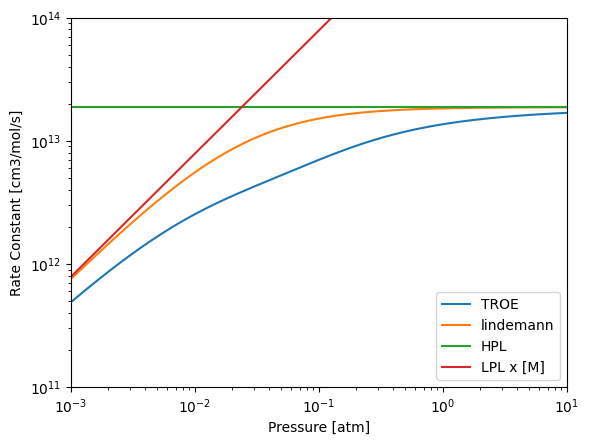

In [5]:
hpl = troe.hpl.rate_constant(T_range)
lpl = troe.lpl.rate_constant(T_range)

k_troe = troe.rate_constant(1000, P_range)

fig, ax = plt.subplots()

ax.plot(P_range, k_troe, label="TROE")
ax.plot(P_range, k_lindemann, label="lindemann")
ax.plot(P_range, hpl, label="HPL")
ax.plot(P_range, lpl*M, label="LPL x [M]")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([1e-3, 1e1])
ax.set_ylim([1e11, 1e14])
ax.set_xlabel("Pressure [atm]")
ax.set_ylabel("Rate Constant [cm3/mol/s]")
ax.legend()
plt.show()

# SRI
- Equations
    > $F = d\left[a\times exp\left(-b/T\right) + exp\left(-T/c\right)\right]^{\chi} T^{e}$
    > 
    > $\chi = \dfrac{1}{1 + log_{10}^{2}P_{r}}$
- CHEMKIN representation
    >```
    > CH3 + H(+M) = CH4(+M)      6.000E+16 -1.000 0.000 
    >  LOW /                     8.000E+26 -3.000 0.000 /
    > SRI  / 0.450 797.00 979.00 1.000 0.000            / ! SRI fall-off coefficients
    > H2/ 2/ CO/ 2/ CO2/ 3/ H2O/ 5/                       ! enhanced third-body efficiencies
    >```
- The rate constant can be represented as a Python object by directly passing a dictionary of parameters to the `FallOff` constructor. The reaction name is optional and may be omitted. Internally, the library performs consistency checks to ensure the physical validity of the provided parameters.
  
  **From dictionary**
    >```python
    > sri = FallOff(
    >     name="CH3+H(+M)=CH4(+M)",
    >     lpl_parameters={"A": 8.000e+26, "n": -3.000, "Ea": 0.000},
    >     hpl_parameters={"A": 6.000e+16, "n": -1.000, "Ea": 0.000},
    >     falloff_parameters={"a": 0.450, "b": 797.00, "c": 979.00, "d": 1., "e": 0.},
    >     falloff_type="sri",
    >     efficiencies={"H2": 2, "CO": 2, "CO2": 3, "H2O": 5},
    > )
    >```

  **From CHEMKIN string**
    >```python
    > sri = FallOff.from_chemkin(
    >     """
    >     CH3+H(+M)=CH4(+M)		8.00000E+26 -3.00000E+00 0.00000E+00
    >     LOW / 6.00000E+16 -1.00000E+00 0.00000E+00 /
    >     SRI / 4.50000E-01 7.97000E+02 9.79000E+02 1.00000E+00 0.00000E+00 /
    >     H2 / 2.00000E+00 / CO / 2.00000E+00 / CO2 / 3.00000E+00 / H2O / 5.00000E+00 /
    >     """
    > )
    >```

In [6]:
# --------------------------------------------------------
# Construction from a python dictionary
sri = FallOff(
    name="CH3+H(+M)=CH4(+M)",
    lpl_parameters={"A": 8.000e+26, "n": -3.000, "Ea": 0.000},
    hpl_parameters={"A": 6.000e+16, "n": -1.000, "Ea": 0.000},
    falloff_parameters={"a": 0.450, "b": 797.00, "c": 979.00, "d": 1., "e": 0.},
    falloff_type="sri",
    efficiencies={"H2": 2, "CO": 2, "CO2": 3, "H2O": 5},
)

# --------------------------------------------------------
# Construction from a CHEMKIN-fromatted string
sri = FallOff.from_chemkin(
    """
    CH3+H(+M)=CH4(+M)		8.00000E+26 -3.00000E+00 0.00000E+00
      LOW / 6.00000E+16 -1.00000E+00 0.00000E+00 /
     SRI / 4.50000E-01 7.97000E+02 9.79000E+02 1.00000E+00 0.00000E+00 /
     H2 / 2.00000E+00 / CO / 2.00000E+00 / CO2 / 3.00000E+00 / H2O / 5.00000E+00 /
    """
)

# --------------------------------------------------------
# Object inspection
print(f"Representer:\n{repr(sri)}\n")
print(f"String representation:\n{str(sri)}") # This always print the CHEMKIN-formatted string

Representer:
FallOff(
 name = CH3+H(+M)=CH4(+M)
 type = sri
 HPL  = Arrhenius(
          name = CH3+H(+M)=CH4(+M) (HPL)
          A    = 8.00000e+26
          n    = -3.00000e+00
          Ea   = 0.00000e+00
         )
 LPL  = Arrhenius(
          name = CH3+H(+M)=CH4(+M) (LPL)
          A    = 6.00000e+16
          n    = -1.00000e+00
          Ea   = 0.00000e+00
         )
 falloff_parameters = {
  a    = 4.50000E-01
  b    = 7.97000E+02
  c    = 9.79000E+02
  d    = 1.00000E+00
  e    = 0.00000E+00
 }
 efficiencies = {
  H2   = 2.00000E+00
  CO   = 2.00000E+00
  CO2  = 3.00000E+00
  H2O  = 5.00000E+00
 }
)

String representation:
CH3+H(+M)=CH4(+M)		8.00000E+26 -3.00000E+00 0.00000E+00
  LOW / 6.00000E+16 -1.00000E+00 0.00000E+00 /
 SRI / 4.50000E-01 7.97000E+02 9.79000E+02 1.00000E+00 0.00000E+00 /
 H2 / 2.00000E+00 / CO / 2.00000E+00 / CO2 / 3.00000E+00 / H2O / 5.00000E+00 /


## TSANG

# TODO